In [1]:
import os, sys
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, matthews_corrcoef

ROOT = r"C:\Users\ACER\Desktop\NeuroNest"
if ROOT not in sys.path:
    sys.path.append(ROOT)

# importing  custom dataset and the resnet model i trained
from ml.pneumonia.training.dataset import ChestXrayDataset
from ml.pneumonia.models.resnet18 import build_resnet18_binary



In [2]:
# paths and settings — change these if you move the files around
CKPT_PATH  = os.path.join(ROOT, "ml", "pneumonia", "checkpoints", "best_resnet18_pneumonia.pth")
VAL_DIR    = os.path.join(ROOT, "Data", "chest_xray", "val")
TEST_DIR   = os.path.join(ROOT, "Data", "chest_xray", "test")

# IMAGE_SIZE must match what the model was trained on
# THRESHOLD is the cutoff — above 0.5 = pneumonia, below = normal
BATCH_SIZE = 32
IMAGE_SIZE = 224
THRESHOLD  = 0.5
CLASSES    = ["NORMAL", "PNEUMONIA"]
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("using device:", DEVICE)
print("checkpoint:", CKPT_PATH)

using device: cuda
checkpoint: C:\Users\ACER\Desktop\NeuroNest\ml\pneumonia\checkpoints\best_resnet18_pneumonia.pth


In [3]:
# loading val and test datasets and wrapping them in dataloaders
# train=False means no augmentation — we want clean unmodified images for evaluation
# test split is optional so we wrap it in a try/except in case the folder doesn't exist
val_ds     = ChestXrayDataset(VAL_DIR,  image_size=IMAGE_SIZE, train=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

try:
    test_ds     = ChestXrayDataset(TEST_DIR, image_size=IMAGE_SIZE, train=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    has_test = True
    print(f"val samples: {len(val_ds)}  |  test samples: {len(test_ds)}")
except Exception as e:
    has_test = False
    print(f"val samples: {len(val_ds)}  (no test split found: {e})")

val samples: 537  |  test samples: 624


In [4]:
# building the resnet model and loading the saved weights
# weights_only=False because the checkpoint also stores extra info like arch name and best F1
model = build_resnet18_binary(pretrained=False).to(DEVICE)
ckpt  = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("model loaded, architecture:", ckpt.get("arch", "resnet18"))
print("best val f1 from training:", f"{ckpt.get('best_val_f1', 'N/A'):.4f}")

model loaded, architecture: resnet18
best val f1 from training: 0.7603


In [5]:
# runs the model on all images in a given loader and collects predicted probabilities
# sigmoid converts the raw model output to a probability between 0 and 1
def run_inference(loader):
    all_probs, all_labels = [], []
    with torch.inference_mode():
        for x, y in tqdm(loader, desc="running inference"):
            x      = x.to(DEVICE)
            probs  = torch.sigmoid(model(x)).cpu().numpy().flatten()
            labels = y.numpy().flatten().astype(int)
            all_probs.extend(probs)
            all_labels.extend(labels)
    return np.array(all_probs), np.array(all_labels)

# run on val and test sets
val_probs, val_labels = run_inference(val_loader)
val_preds = (val_probs >= THRESHOLD).astype(int)

if has_test:
    test_probs, test_labels = run_inference(test_loader)
    test_preds = (test_probs >= THRESHOLD).astype(int)

print("done!")

running inference:   0%|          | 0/17 [00:00<?, ?it/s]

running inference:   0%|          | 0/20 [00:00<?, ?it/s]

done!


In [7]:
# computing all the evaluation metrics from the predictions
# MCC (Matthews Correlation Coefficient) is a good overall metric when classes are imbalanced
def compute_metrics(labels, preds, split_name):
    tp  = int(((preds==1)&(labels==1)).sum())
    tn  = int(((preds==0)&(labels==0)).sum())
    fp  = int(((preds==1)&(labels==0)).sum())
    fn  = int(((preds==0)&(labels==1)).sum())
    eps = 1e-9

    acc  = (tp+tn) / (tp+tn+fp+fn+eps)
    prec = tp / (tp+fp+eps)
    rec  = tp / (tp+fn+eps)       # also called sensitivity
    spec = tn / (tn+fp+eps)       # true negative rate
    f1   = 2*prec*rec / (prec+rec+eps)
    mcc  = matthews_corrcoef(labels, preds)

    m = dict(Accuracy=acc, Precision=prec, Recall=rec, Specificity=spec, F1=f1, MCC=mcc,
             TP=tp, TN=tn, FP=fp, FN=fn)

    print(f"\n{split_name} results:")
    for k, v in m.items():
        if k not in ("TP", "TN", "FP", "FN"):
            print(f"  {k:<14}: {v:.4f}")
    print(f"  counts        : TP={tp}  TN={tn}  FP={fp}  FN={fn}")
    return m

val_m = compute_metrics(val_labels, val_preds, "validation")
if has_test:
    test_m = compute_metrics(test_labels, test_preds, "test")


validation results:
  Accuracy      : 0.9888
  Precision     : 0.9924
  Recall        : 0.9924
  Specificity   : 0.9789
  F1            : 0.9924
  MCC           : 0.9713
  counts        : TP=392  TN=139  FP=3  FN=3

test results:
  Accuracy      : 0.8542
  Precision     : 0.8134
  Recall        : 0.9949
  Specificity   : 0.6197
  F1            : 0.8950
  MCC           : 0.7011
  counts        : TP=388  TN=145  FP=89  FN=2


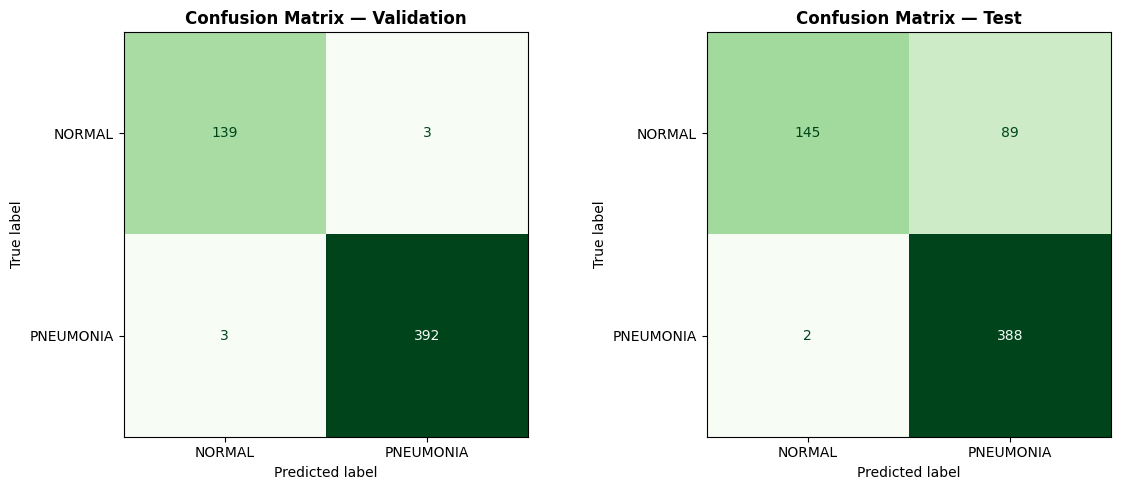

In [8]:
# plotting confusion matrices for val and test side by side
# rows = actual labels, columns = predicted labels
# ideally we want high numbers on the diagonal (top-left and bottom-right)
splits = [("Validation", val_labels, val_preds)]
if has_test:
    splits.append(("Test", test_labels, test_preds))

fig, axes = plt.subplots(1, len(splits), figsize=(6 * len(splits), 5))
if len(splits) == 1:
    axes = [axes]

for ax, (name, labels, preds) in zip(axes, splits):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    ax.set_title(f"Confusion Matrix — {name}", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()